# M13 · ANN / Vector Search & Indexing — Hands-on, for a Total Beginner

**Companion to lesson M13. Assumes you know nothing about vector search.**

Here's the situation. In earlier modules we turned things (creators, queries, ads) into
**vectors** — lists of numbers — where *similar things have similar vectors*. Now a request
comes in, we turn it into a vector too, and we need to find the **nearest** item vectors (the
best matches). The problem: there can be **millions** of item vectors.

- **Exact search** checks the query against *every single* item. Always correct, but **slow**.
- **Approximate search (ANN)** is clever: it checks only a **small fraction** of items and still
  usually finds the right answers. Much faster, at the cost of *occasionally* missing one.

That trade — **a little accuracy for a lot of speed** — is the entire subject of this module.

We'll build tiny working versions of the three main ANN methods, **one small idea at a time**,
with a picture and plain-English explanation for each:
- **A · Why we need ANN** — feel the speed problem; learn how we *grade* accuracy (recall@k).
- **B · IVF** — split items into groups, only look in the nearest groups.
- **C · PQ** — squash each vector into a few bytes to save memory.
- **D · IVF-PQ** — do both at once.
- **E · HNSW** — connect items into a network and "walk" to the answer.
- **F · ScaNN idea** — score everything cheaply, then double-check a few.
- **G · Choosing & tuning** — how to pick a method and dial it in.

Uses **scikit-learn** + **matplotlib** (already in Colab — nothing to install). Run each cell
with **Shift+Enter**. Take your time; every step explains itself.

## Step 1 · Setup — make some pretend data to search

Before any searching, we need a pile of vectors to search *through*. We'll **make up** a
synthetic set so we fully control it (real embeddings would come from M11/M12, but the search
machinery is identical).

**What the code below does, line by line:**
- `N, DIM = 6000, 32` → we'll create **6,000** items, each a vector of **32** numbers.
- We make **30 "cluster centers"** and scatter items around them — so the data naturally forms
  clumps (just like real embeddings, where similar items group together).
- `X` is the big table of item vectors (6000 rows × 32 columns).
- `Q` is a set of **300 test queries** — we make each query by taking a real item and nudging it
  slightly, so we *know* roughly what its correct answer should be.
- `exact_topk(q)` is our **"answer key"**: it compares a query to *every* item and returns the
  true top-k. Every method we build gets graded against this.

In [2]:
import numpy as np, pandas as pd, time, heapq
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

rng = np.random.default_rng(0)
N, DIM = 6000, 32
lab = rng.integers(0, 30, N)                         # which of 30 clusters each item belongs to
centers = rng.normal(0, 1, (30, DIM))                # the 30 cluster centers
X = (centers[lab] + rng.normal(0, 0.4, (N, DIM))).astype(np.float32)   # 6000 item vectors
Q = (X[rng.choice(N, 300, replace=False)] + rng.normal(0, 0.2, (300, DIM))).astype(np.float32)  # 300 queries

# our "answer key": the TRUE nearest items, found the slow/correct way (check everything)
def exact_topk(q, k=20): return set(np.argsort(-(X @ q))[:k])
def recall_of(fn, k=20):                              # average score of a method over all queries
    return float(np.mean([len(exact_topk(q, k) & fn(q, k)) / k for q in Q]))

print(f"we have {N} item vectors, each with {DIM} numbers")
print(f"and {len(Q)} test queries to search with")
print(f"one vector takes {DIM} numbers x 4 bytes = {DIM*4} bytes of memory")

we have 6000 item vectors, each with 32 numbers
and 300 test queries to search with
one vector takes 32 numbers x 4 bytes = 128 bytes of memory


---
# Part A · Why we need ANN (and how we grade it)

## Step 2 · The speed problem — "check everything" gets slow

**Analogy.** Imagine finding the closest coffee shop by **walking to every single shop in the
city** and measuring the distance. Correct — but if the city has a million shops, you'll be
walking forever. That's exact search.

**The idea.** Exact search does one comparison **per item**. Double the items → double the work.
We call that "linear" cost. It's fine for a few thousand items, but at millions it's too slow
for a website that must answer in a few milliseconds.

**What the code does:** we time exact search on corpora of 10k, 50k, and 200k vectors and print
milliseconds per query. Watch the time grow *in step* with the size.

time to search ONE query, as the pile of items grows:
   10,000 items:    1.0 ms per query
   50,000 items:    6.0 ms per query
  200,000 items:   23.0 ms per query


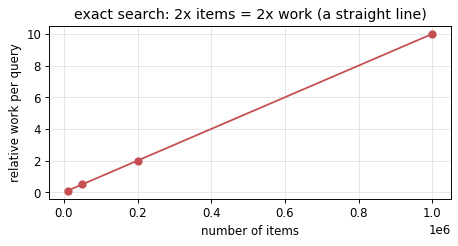

In [5]:
print("time to search ONE query, as the pile of items grows:")
for n in [10_000, 50_000, 200_000]:
    Xn = rng.normal(0, 1, (n, 64)).astype(np.float32); qn = rng.normal(0, 1, 64).astype(np.float32)
    t = time.perf_counter()
    for _ in range(20): np.argsort(-(Xn @ qn))[:10]     # score ALL n items, take top 10
    dt = (time.perf_counter() - t) / 20
    print(f"  {n:>7,} items: {dt*1000:6.1f} ms per query")

plt.figure(figsize=(5.5,3))
ns = [10_000, 50_000, 200_000, 1_000_000]
plt.plot(ns, [n/1e5 for n in ns], "o-", color=RED)
plt.xlabel("number of items"); plt.ylabel("relative work per query")
plt.title("exact search: 2x items = 2x work (a straight line)"); plt.show()

**How to read this:** the time roughly **doubles when the item count doubles**, and the plot is
a **straight line** — that's what "linear cost" means. Now imagine the x-axis going to
*millions*. The line keeps climbing, blowing past your latency budget. **ANN's whole job is to
break this line** by *not* checking every item.

## Step 3 · How do we grade "approximate"? — recall@k

If a method skips items, it might **miss** some true neighbors. We need a score for "how many
did it still find." That score is **recall@k**.

**Plain words:** line up the **true** best-k answers (from our answer key) and the method's
**approximate** best-k. **recall@k = how many of the true ones the method actually returned,
divided by k.** 1.0 = found them all; 0.5 = found half.

$$\text{recall@}k=\frac{\text{(true top-}k)\ \cap\ \text{(approx top-}k)}{k}$$

**What the code does:** we hand-write a tiny example — a true list and an approximate list — and
compute recall at k=1, 3, 5 so you can see exactly where the fraction comes from.

In [8]:
true_best   = [9, 3, 7, 2, 5, 1]        # the correct nearest items, best first (from the answer key)
approx_best = [9, 7, 2, 8, 4, 0]        # what some approximate method returned

for k in [1, 3, 5]:
    found = set(approx_best[:k]) & set(true_best[:k])       # which true top-k did we recover?
    print(f"  recall@{k}: true top-{k}={true_best[:k]}")
    print(f"            approx  ={approx_best[:k]}  ->  recovered {sorted(found)}  =  {len(found)}/{k} = {len(found)/k:.2f}")

  recall@1: true top-1=[9]
            approx  =[9]  ->  recovered [9]  =  1/1 = 1.00
  recall@3: true top-3=[9, 3, 7]
            approx  =[9, 7, 2]  ->  recovered [7, 9]  =  2/3 = 0.67
  recall@5: true top-5=[9, 3, 7, 2, 5]
            approx  =[9, 7, 2, 8, 4]  ->  recovered [2, 7, 9]  =  3/5 = 0.60


**How to read this:** at **k=3**, the true top-3 is `[9,3,7]` and the method returned `[9,7,2]`.
It got `9` and `7` right but **missed `3`** (and included `2`, which wasn't in the true top-3).
So recall@3 = **2/3 = 0.67**. Higher recall = fewer misses. From here on, **every method is
scored this way against the answer key.**

---
# Part B · IVF — split into groups, search the nearest groups

## Step 4 · IVF idea 1 — put items into groups (cells)

**Analogy.** A library doesn't dump every book in one pile — it groups them into **sections**
(history, science, cooking). To find a cooking book you walk to the cooking section, not the
whole building. **IVF does exactly this with vectors.**

**Plain words.** IVF ("Inverted File") uses **k-means clustering** to split all items into
`nlist` **groups called cells**. Each cell has a **center point** (a "centroid"). Every item is
filed under its **nearest** centroid. That's a one-time setup, done offline.

**What the code does:** to make it *visible*, we first do this in **2D** (just 2 numbers per
point, so we can draw it). We cluster a small 2D set into 8 cells and plot them in different
colors, with the centroids marked as big X's.

every point is now filed under its nearest black X. 8 cells = 8 'sections' of the library.


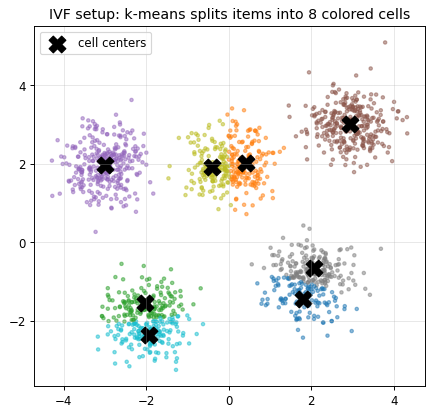

In [12]:
# a tiny 2D dataset so we can actually SEE the groups (real vectors have 32+ dims, can't draw those)
X2 = np.vstack([rng.normal(c, 0.5, (300, 2)) for c in [(-2,-2),(0,2),(2,-1),(3,3),(-3,2)]]).astype(np.float32)
km2 = KMeans(8, n_init=3, random_state=0).fit(X2)     # split into 8 cells
cents2 = km2.cluster_centers_                          # the 8 center points

plt.figure(figsize=(5.2,5))
plt.scatter(X2[:,0], X2[:,1], c=km2.labels_, cmap="tab10", s=8, alpha=.5)   # color = which cell
plt.scatter(cents2[:,0], cents2[:,1], marker="X", s=200, color="k", label="cell centers")
plt.legend(); plt.title("IVF setup: k-means splits items into 8 colored cells"); plt.show()
print("every point is now filed under its nearest black X. 8 cells = 8 'sections' of the library.")

**How to read this:** each **color is one cell**, and each **black X is that cell's center**.
The clumps of points got sorted into nearby cells. Nothing has been searched yet — this is just
the **filing system**. Next we use it to search *fast*.

## Step 5 · IVF idea 2 — only search the nearest cells (probing)

**Plain words.** When a query arrives, we **don't** open every cell. We look at the **cell
centers**, find the `nprobe` centers **closest to the query**, and only search **inside those
cells**. `nprobe` = "how many sections of the library do I walk into?"

- `nprobe` small → search few cells → **fast**, but you might **miss** a good item sitting in a
  cell you didn't open.
- `nprobe` large → search more cells → **slower**, but you miss less.

**What the code does:** we drop a query (red star) into the 2D map, find its 2 nearest cells,
and circle the points we'd actually search. Then we print, for `nprobe` = 1, 2, 3, **how many
of the 1500 points we ended up scanning.**

  nprobe=1: open 1 nearest cell(s) -> only search 161 of 1500 points
  nprobe=2: open 2 nearest cell(s) -> only search 302 of 1500 points
  nprobe=3: open 3 nearest cell(s) -> only search 602 of 1500 points


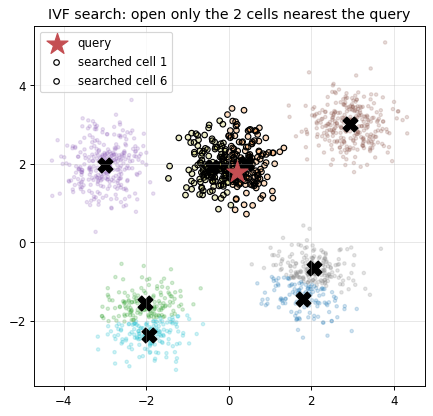

In [15]:
q2 = np.array([0.2, 1.8], dtype=np.float32)                    # a query somewhere in the 2D map
plt.figure(figsize=(5.2,5))
plt.scatter(X2[:,0], X2[:,1], c=km2.labels_, cmap="tab10", s=8, alpha=.2)
plt.scatter(cents2[:,0], cents2[:,1], marker="X", s=160, color="k")
plt.scatter(*q2, marker="*", s=350, color=RED, label="query", zorder=5)
near2 = np.argsort(np.linalg.norm(cents2 - q2, axis=1))[:2]     # the 2 nearest cell centers (nprobe=2)
for c in near2:
    pts = X2[km2.labels_ == c]
    plt.scatter(pts[:,0], pts[:,1], s=22, edgecolor="k", facecolor="none", label=f"searched cell {c}")
plt.legend(); plt.title("IVF search: open only the 2 cells nearest the query"); plt.show()

for nprobe in [1, 2, 3]:
    near = np.argsort(np.linalg.norm(cents2 - q2, axis=1))[:nprobe]
    scanned = sum((km2.labels_ == c).sum() for c in near)
    print(f"  nprobe={nprobe}: open {nprobe} nearest cell(s) -> only search {scanned} of {len(X2)} points")

**How to read this:** the **circled points** are the only ones we compare against the query —
everything else is skipped. With `nprobe=1` we search ~10% of the data; even `nprobe=3` is under
half. **That skipping is the speed win.** The risk: if the query sits near a *border*, the true
nearest item might be just inside an unopened cell — that's how IVF loses a bit of recall.

## Step 6 · IVF on the real 6,000-item corpus — turning the knob

Now the same two ideas on the real 32-dim data. We build 64 cells, then **sweep `nprobe`** and
measure two things per setting: **recall@20** (accuracy) and **% of items scanned** (a stand-in
for time). This table *is* the IVF tradeoff.

IVF over 6000 items in 64 cells

 nprobe  recall@20  % scanned
      1       0.64       1.7%
      2       0.94       3.2%
      4       1.00       6.1%
      8       1.00      12.2%
     16       1.00      24.3%
     32       1.00      49.0%


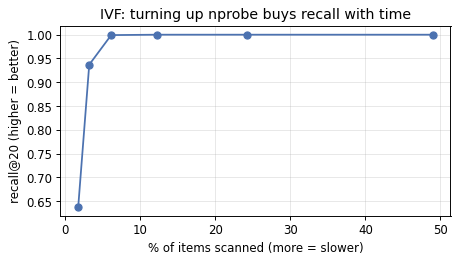

In [18]:
nlist = 64
km = KMeans(nlist, n_init=3, random_state=0).fit(X)           # 64 cells over the real corpus
cents = km.cluster_centers_
members = [np.where(km.labels_ == c)[0] for c in range(nlist)]  # the list of items in each cell

def ivf(q, k=20, nprobe=8):
    near = np.argsort(-(cents @ q))[:nprobe]                   # nearest `nprobe` cell centers
    cand = np.concatenate([members[c] for c in near])         # gather items in those cells
    if len(cand) < k: return set(cand)
    return set(cand[np.argsort(-(X[cand] @ q))[:k]])          # rank ONLY those items, take top k

print(f"IVF over {N} items in {nlist} cells\n")
print(f"{'nprobe':>7}{'recall@20':>11}{'% scanned':>11}")
ivf_rows = []
for nprobe in [1, 2, 4, 8, 16, 32]:
    rec = recall_of(lambda q, k: ivf(q, k, nprobe))
    scanned = np.mean([sum(len(members[c]) for c in np.argsort(-(cents@q))[:nprobe]) for q in Q]) / N
    ivf_rows.append((nprobe, rec, scanned*100)); print(f"{nprobe:>7}{rec:>11.2f}{scanned*100:>10.1f}%")
plt.figure(figsize=(5.5,3.2))
plt.plot([r[2] for r in ivf_rows], [r[1] for r in ivf_rows], "o-", color=BLUE)
plt.xlabel("% of items scanned (more = slower)"); plt.ylabel("recall@20 (higher = better)")
plt.title("IVF: turning up nprobe buys recall with time"); plt.show()

**How to read this:** look at `nprobe=2` — scanning just **~3% of the items** already gives
**~0.94 recall**. That's the headline: IVF finds almost all the right answers while skipping
**97%** of the work. Turning `nprobe` higher pushes recall toward 1.0 but scans more (slower).
**You choose the row that meets your accuracy need at the lowest cost** — that's the whole game
(we formalize it in Part G).

---
# Part C · PQ — squash each vector to save memory

## Step 7 · PQ idea 1 — chop each vector into pieces

**A different problem.** IVF made search *faster*. **PQ (Product Quantization) makes storage
smaller.** Why care? Millions of 32-number vectors eat gigabytes of RAM; PQ can shrink that by
10–50×.

**Analogy.** Instead of storing a color as exact numbers (R=137, G=42, B=200), imagine a box of
**256 crayons**. You store just the **crayon number** closest to your color (1 byte) instead of
three exact values. You lose a tiny bit of precision, save a lot of space. PQ does this — but it
first **chops the vector into pieces** and crayon-codes each piece separately.

**What the code does:** we split each 32-number vector into `m=8` **subvectors** of 4 numbers
each, and print item 0's eight pieces so you can see the chopping.

In [22]:
m = 8; sub = DIM // m                              # 32 numbers -> 8 pieces of 4 numbers each
print(f"one vector = {DIM} numbers = {DIM*4} bytes")
print(f"we chop it into m={m} subvectors of {sub} numbers each.\n")
print("item 0, chopped into 8 pieces:")
for s in range(m):
    print(f"   piece {s}: {X[0, s*sub:(s+1)*sub].round(2)}")

one vector = 32 numbers = 128 bytes
we chop it into m=8 subvectors of 4 numbers each.

item 0, chopped into 8 pieces:
   piece 0: [ 0.34 -0.39  1.44 -0.01]
   piece 1: [ 0.12 -0.09 -1.78  0.65]
   piece 2: [ 0.96  0.94 -1.21  0.53]
   piece 3: [ 1.64  2.76  0.26 -0.04]
   piece 4: [-1.54 -0.17 -1.06  0.57]
   piece 5: [-0.91 -0.3   0.6  -0.07]
   piece 6: [ 0.54 -0.38  0.5  -1.31]
   piece 7: [ 0.5  -1.37 -0.   -0.42]


**How to read this:** item 0's 32 numbers are now shown as **8 little pieces of 4 numbers**.
Nothing is compressed yet — we've just cut the vector into 8 parts. Next, each *part* gets its
own crayon box.

## Step 8 · PQ idea 2 — build a "crayon box" (codebook) for each piece

**Plain words.** For each piece position (piece 0, piece 1, …), we look at that piece across
**all 6,000 items** and run **k-means to find 256 representative pieces** — that's the **codebook**
(the crayon box) for that position. Now any 4-number piece can be replaced by the **number of
its nearest crayon** (0–255), which fits in **1 byte**.

So an item's whole vector becomes **8 crayon-numbers = 8 bytes** (down from 128 bytes).

**What the code does:** build 8 codebooks (one per piece), replace every item's pieces with
crayon-numbers (`codes`), and print item 0's new 8-byte code.

In [25]:
ksub = 256                                         # 256 crayons per box -> each choice fits in 1 byte
codebooks, codes = [], np.zeros((N, m), dtype=np.uint8)
for s in range(m):
    piece = X[:, s*sub:(s+1)*sub]                  # this piece-position across all items
    kms = KMeans(ksub, n_init=2, random_state=0).fit(piece)   # find 256 representative pieces
    codebooks.append(kms.cluster_centers_.astype(np.float32)) # the "crayon box" for this position
    codes[:, s] = kms.labels_                       # each item's piece -> its nearest crayon number
    if s < 3: print(f"  piece {s}: crayon box has shape {kms.cluster_centers_.shape} (256 crayons x {sub} numbers)")
print(f"  ... 8 crayon boxes total\n")
print(f"item 0 used to be 32 numbers ({DIM*4} bytes).")
print(f"item 0 is now the code {codes[0]}  =  just {m} bytes (8 crayon numbers).")

  piece 0: crayon box has shape (256, 4) (256 crayons x 4 numbers)
  piece 1: crayon box has shape (256, 4) (256 crayons x 4 numbers)
  piece 2: crayon box has shape (256, 4) (256 crayons x 4 numbers)
  ... 8 crayon boxes total

item 0 used to be 32 numbers (128 bytes).
item 0 is now the code [183  47 242 114  98 207 241  38]  =  just 8 bytes (8 crayon numbers).


**How to read this:** item 0 is now **8 small integers** like `[183, 47, 242, …]` — each says
"for this piece, use crayon #183." We threw away the exact numbers and kept only *which crayon
was closest*. That's a **16× memory cut** (128 bytes → 8 bytes). But we clearly lost some detail
— the next step measures how much.

## Step 9 · PQ's trade — big memory savings, a little accuracy lost

**Plain words.** To search with codes, we **reconstruct** an approximate vector by looking up
each crayon (`codebooks[s][codes[:,s]]`). It's *close* to the original but not exact — the gap
is called **quantization error**. Because the vectors are now slightly wrong, the search misses
a few neighbors, so **recall drops**. We measure the memory saved *and* the recall lost.

memory:  768 KB (real)  ->  48 KB (codes)   = 16x smaller
accuracy cost: average gap between real and rebuilt vector = 1.25

recall@20:  real vectors 1.00  ->  PQ crayon vectors 0.59


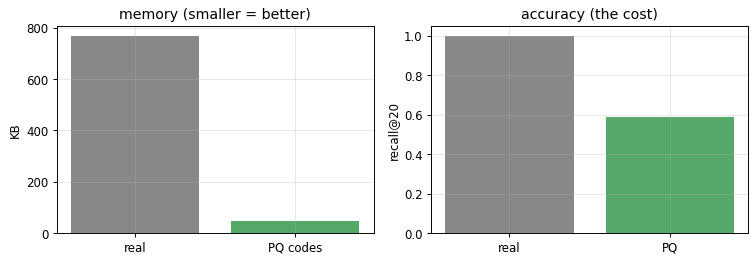

In [28]:
Xpq = np.concatenate([codebooks[s][codes[:, s]] for s in range(m)], axis=1)  # rebuild approx vectors from crayons
full_bytes, code_bytes = X.nbytes, codes.nbytes
recon_err = np.linalg.norm(X - Xpq, axis=1).mean()             # how far the approx is from the real vector

print(f"memory:  {full_bytes/1e3:.0f} KB (real)  ->  {code_bytes/1e3:.0f} KB (codes)   = {full_bytes/code_bytes:.0f}x smaller")
print(f"accuracy cost: average gap between real and rebuilt vector = {recon_err:.2f}\n")
rec_pq   = recall_of(lambda q, k: set(np.argsort(-(Xpq @ q))[:k]))    # search using the crayon-rebuilt vectors
rec_full = recall_of(lambda q, k: exact_topk(q, k))
print(f"recall@20:  real vectors {rec_full:.2f}  ->  PQ crayon vectors {rec_pq:.2f}")
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].bar(["real","PQ codes"], [full_bytes/1e3, code_bytes/1e3], color=[GRAY, GREEN]); ax[0].set_ylabel("KB"); ax[0].set_title("memory (smaller = better)")
ax[1].bar(["real","PQ"], [rec_full, rec_pq], color=[GRAY, GREEN]); ax[1].set_ylabel("recall@20"); ax[1].set_title("accuracy (the cost)")
plt.show()

**How to read this:** memory dropped **16×** (great!), but recall fell from **1.00 to ~0.59**
(ouch). PQ *alone* is too lossy to serve. The fix is coming in Part D: **use PQ's cheap codes to
pick candidates, then double-check the top few with the real vectors** — best of both worlds.

---
# Part D · IVF-PQ — do both, then double-check

## Step 10 · Combine grouping + squashing + a final exact check

**Plain words.** The real production index is **IVF-PQ**, which stacks everything so far:
1. **IVF**: only look in the nearest cells (skip most items) → *fast*.
2. **PQ**: store items as tiny crayon-codes → *small memory*.
3. **Rerank**: PQ codes are rough, so use them only to pick a **shortlist**, then **re-score that
   shortlist with the real vectors** to get the order right → *recovers accuracy*.

**Analogy.** Skim the whole shelf quickly with blurry vision (PQ), grab the 200 most promising
books, then put your glasses on and carefully compare just those 200 (rerank).

**What the code does:** `ivf_pq` probes cells (IVF), ranks candidates with the cheap crayon
vectors, keeps the top `rerank=200`, and **re-ranks those 200 with the exact vectors**. We
compare its recall and memory to plain IVF.

In [32]:
def ivf_pq(q, k=20, nprobe=8, rerank=200):
    near = np.argsort(-(cents @ q))[:nprobe]                  # 1. IVF: pick nearest cells
    cand = np.concatenate([members[c] for c in near])        #    gather their items
    if len(cand) < k: return set(cand)
    shortlist = cand[np.argsort(-(Xpq[cand] @ q))[:rerank]]  # 2. PQ: cheaply rank -> keep top 200
    return set(shortlist[np.argsort(-(X[shortlist] @ q))[:k]])  # 3. rerank those 200 with REAL vectors

r_ivf   = recall_of(lambda q, k: ivf(q, k, nprobe=8))
r_ivfpq = recall_of(lambda q, k: ivf_pq(q, k, nprobe=8))
print("at nprobe=8:")
print(f"  plain IVF (stores real vectors)  : recall {r_ivf:.2f},  memory {X.nbytes/1e3:.0f} KB")
print(f"  IVF-PQ   (stores crayon codes)   : recall {r_ivfpq:.2f},  memory {codes.nbytes/1e3:.0f} KB  ({X.nbytes/codes.nbytes:.0f}x less)")

at nprobe=8:
  plain IVF (stores real vectors)  : recall 1.00,  memory 768 KB
  IVF-PQ   (stores crayon codes)   : recall 1.00,  memory 48 KB  (16x less)


**How to read this:** IVF-PQ matches IVF's recall (~1.00) while using **16× less memory**. The
**rerank step is what saved it** — PQ picked a good shortlist cheaply, and the exact re-score
fixed the ordering PQ got slightly wrong. This "cheap filter → exact recheck" pattern shows up
again in ScaNN (Part F).

---
# Part E · HNSW — build a network and walk to the answer

## Step 11 · HNSW idea 1 — connect each item to its neighbors

**Analogy.** Think of **"six degrees of separation."** To reach a stranger, you don't scan the
whole planet — you ask a friend "who do you know closer to this person?", hop to them, and
repeat. A few hops and you're there. **HNSW builds that social network for vectors and walks it.**

**Plain words.** HNSW ("Hierarchical Navigable Small World") is a **graph**: each item is a node
**linked to its nearest neighbors**. We also sprinkle in a few **long-range links** (random far
shortcuts) — these are the "friend in another city" that lets the walk jump across the space
fast instead of crawling neighbor-by-neighbor.

**What the code does:** for every item, find its 16 nearest neighbors (the local links) and add
4 random long-range links. `graph[i]` is then the list of nodes you can hop to from item `i`.

In [36]:
knn = NearestNeighbors(n_neighbors=16).fit(X); _, nn_graph = knn.kneighbors(X)   # 16 nearest neighbors each
long_range = rng.integers(0, N, (N, 4))                    # 4 random far shortcuts per node
graph = np.concatenate([nn_graph, long_range], axis=1)     # each node's hop options

print(f"built a graph over {N} items:")
print(f"  each node links to {nn_graph.shape[1]} NEAR neighbors (keeps the walk accurate)")
print(f"  plus {long_range.shape[1]} LONG-RANGE shortcuts (lets the walk cross the space quickly)")
print(f"\nfrom item 0 you can hop to: {graph[0][:8]} ...")

built a graph over 6000 items:
  each node links to 16 NEAR neighbors (keeps the walk accurate)
  plus 4 LONG-RANGE shortcuts (lets the walk cross the space quickly)

from item 0 you can hop to: [   0   25 4221 5813 4042 3984 3387 3683] ...


**How to read this:** each item is now a node with ~20 "who do you know" links. **Near links**
keep you from overshooting; **long-range links** stop you from crawling one tiny step at a time.
We haven't searched yet — this is the network. Next we *walk* it.

## Step 12 · HNSW idea 2 — the greedy walk (watch it climb)

**Plain words.** To search: **start at some node**, look at its linked neighbors, **hop to
whichever neighbor is closest to the query**, and repeat. Stop when no neighbor is closer than
where you are (you've arrived). Each hop gets you *closer* — the similarity to the query goes
**up** every step.

**What the code does:** we deliberately **start at the WORST possible node** (farthest from the
query) so you can watch the walk climb all the way up. We record each hop's similarity and plot
the climb.

the walk took 5 hops to settle.
similarity to the query at each hop: [-17.9, 3.3, 47.7, 51.6, 54.6]
notice it goes UP every hop -- the walk climbs toward the best match.


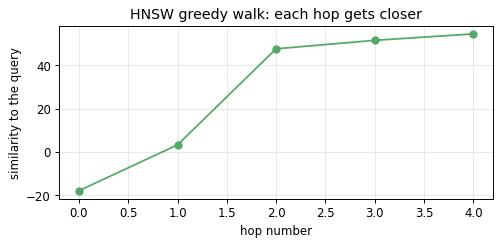

In [39]:
qv = X[rng.integers(0, N)] + rng.normal(0, 0.2, DIM)       # the query (near some real item)
cur = int(np.argmin(X @ qv)); path = [cur]                 # START at the FARTHEST node (worst case)
for _ in range(50):
    neigh = graph[cur]
    best = int(neigh[np.argmax(X[neigh] @ qv)])            # the neighbor closest to the query
    if X[best] @ qv <= X[cur] @ qv: break                  # nobody's closer -> we've arrived
    cur = best; path.append(cur)                           # hop there, repeat

sims = [float(X[p] @ qv) for p in path]
print(f"the walk took {len(path)} hops to settle.")
print(f"similarity to the query at each hop: {[round(s,1) for s in sims]}")
print("notice it goes UP every hop -- the walk climbs toward the best match.")
plt.figure(figsize=(6,3)); plt.plot(sims, "o-", color=GREEN)
plt.xlabel("hop number"); plt.ylabel("similarity to the query")
plt.title("HNSW greedy walk: each hop gets closer"); plt.show()

**How to read this:** we started at the **worst** node (big negative similarity) and each hop
**climbed** — the first long-range shortcut jumps us into the right neighborhood, then near-links
fine-tune to the best match. It reached a great answer in a **handful of hops**, touching only a
tiny fraction of the 6,000 items. That's the graph magic.

## Step 13 · HNSW idea 3 — the accuracy knob (efSearch)

**Plain words.** A single greedy path can get **stuck** at a "local best" (a node better than
all its neighbors but not the true best). The fix: instead of tracking just the current node,
keep a **shortlist of the `efSearch` best-so-far** and keep exploring from all of them. Bigger
`efSearch` = explore more paths = higher recall, but visit more nodes (slower).

**What the code does:** a proper HNSW search that keeps an `efSearch`-sized shortlist. We sweep
`efSearch` and report recall@20 and how many nodes it visited.

 efSearch  recall@20  nodes visited  (out of 6000)
       10       0.43            212
       20       0.71            294
       40       0.84            399
       80       0.91            576
      160       0.94            872


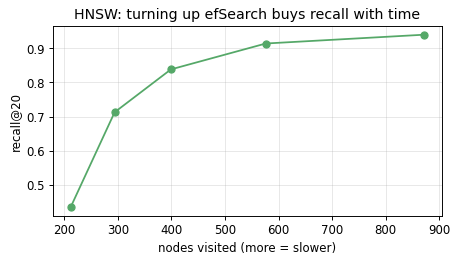

In [42]:
def hnsw(q, k=20, efSearch=40):
    dist = lambda i: -float(X[i] @ q)                       # smaller = closer to the query
    entry = int(rng.integers(0, N)); d0 = dist(entry)
    cand = [(d0, entry)]; res = [(-d0, entry)]; seen = {entry}; visited = 1
    while cand:
        cd, c = heapq.heappop(cand)                         # the most promising unexplored node
        if cd > -res[0][0]: break                           # even the best candidate is worse than our shortlist -> stop
        for e in graph[c]:                                  # look at its neighbors
            if e in seen: continue
            seen.add(e); visited += 1; de = dist(e)
            if de < -res[0][0] or len(res) < efSearch:      # good enough to keep?
                heapq.heappush(cand, (de, e)); heapq.heappush(res, (-de, e))
                if len(res) > efSearch: heapq.heappop(res)  # keep the shortlist to size efSearch
    return set(e for _, e in heapq.nlargest(k, res)), visited

print(f"{'efSearch':>9}{'recall@20':>11}{'nodes visited':>15}  (out of {N})")
hnsw_rows = []
for ef in [10, 20, 40, 80, 160]:
    recs = [len(exact_topk(q,20) & hnsw(q,20,ef)[0])/20 for q in Q]
    vis  = [hnsw(q,20,ef)[1] for q in Q]
    hnsw_rows.append((ef, np.mean(recs), np.mean(vis)))
    print(f"{ef:>9}{np.mean(recs):>11.2f}{np.mean(vis):>15.0f}")
plt.figure(figsize=(5.5,3.2))
plt.plot([r[2] for r in hnsw_rows], [r[1] for r in hnsw_rows], "o-", color=GREEN)
plt.xlabel("nodes visited (more = slower)"); plt.ylabel("recall@20")
plt.title("HNSW: turning up efSearch buys recall with time"); plt.show()

**How to read this:** same shape of trade as IVF's `nprobe`. At `efSearch=160` we reach **~0.94
recall** while visiting only **~880 of 6,000** nodes (~15%). Small `efSearch` is faster but
misses more. **`efSearch` is HNSW's recall-vs-speed dial**, just like `nprobe` was for IVF.

---
# Part F · ScaNN idea — score cheap, then double-check a few

## Step 14 · The "blurry pass, then sharp pass" pattern

**Plain words.** You already saw this trick in IVF-PQ's rerank. **ScaNN** is a Google index
built around it: **score every item with a cheap, blurry approximation, take a shortlist, then
re-score just the shortlist with the exact vectors.** ScaNN's clever part is *how* it blurs
(anisotropic quantization — it keeps precision where it matters most for ranking), but the
skeleton is the same cheap→exact funnel.

**What the code does:** we fake the "blurry" vectors by rounding (cheap, low precision), score
all items with them, take the top 200, and rerank those 200 exactly.

In [46]:
Xcoarse = np.round(X * 4) / 4                       # a cheap, blurry version of every vector
def scann_like(q, k=20, pool=200):
    shortlist = np.argsort(-(Xcoarse @ q))[:pool]   # 1. BLURRY pass: score everything cheaply, keep top 200
    return set(shortlist[np.argsort(-(X[shortlist] @ q))[:k]])   # 2. SHARP pass: rerank those 200 exactly
r_scann = recall_of(lambda q, k: scann_like(q, k))
print(f"blurry-score everything -> sharp-rerank the top 200:  recall@20 = {r_scann:.2f}")
print("almost perfect recall, but the expensive exact math ran on only 200 items, not 6000.")

blurry-score everything -> sharp-rerank the top 200:  recall@20 = 1.00
almost perfect recall, but the expensive exact math ran on only 200 items, not 6000.


**How to read this:** recall is ~**1.00** even though the exact (expensive) comparison touched
only **200** items. The blurry pass is cheap enough to run on everything; the sharp pass is
accurate but runs on a tiny shortlist. **This funnel — cheap filter, exact recheck — is the
backbone of most fast, accurate vector search.**

---
# Part G · Choosing a method and tuning it

## Step 15 · The three families at a glance

We've now built all three. Here's how each **avoids checking every item**, in one table.

In [50]:
fams = pd.DataFrame({
    "family": ["IVF (grouping)", "PQ / IVF-PQ (squashing)", "HNSW (network)", "ScaNN (blurry+sharp)"],
    "trick": ["only open nearby cells", "store tiny crayon-codes",
              "walk a neighbor graph", "cheap score, then exact recheck"],
    "main dial": ["nprobe", "code size / rerank", "efSearch", "shortlist size"],
    "downside": ["can miss items in unopened cells", "codes are lossy (needs rerank)",
                 "graph uses lots of memory", "depends on the implementation"],
})
print(fams.to_string(index=False))

                 family                           trick          main dial                         downside
         IVF (grouping)          only open nearby cells             nprobe can miss items in unopened cells
PQ / IVF-PQ (squashing)         store tiny crayon-codes code size / rerank   codes are lossy (needs rerank)
         HNSW (network)           walk a neighbor graph           efSearch        graph uses lots of memory
   ScaNN (blurry+sharp) cheap score, then exact recheck     shortlist size    depends on the implementation


## Step 16 · Tuning = pick the cheapest setting that's accurate enough

**Plain words.** There is **no single best method or setting** — it depends on your accuracy
requirement and speed budget. The routine: run a **knob sweep**, plot **recall vs work**, and
pick the **cheapest point that clears your recall bar**. Points that another point beats on
*both* axes are "dominated" — never pick those.

**What the code does:** plot IVF's and HNSW's sweeps together (recall on the y-axis, work on the
x-axis), draw a recall bar at 0.90, and print the cheapest IVF setting that clears it.

cheapest IVF setting that clears recall 0.9: nprobe=2  ->  0.94 recall while scanning only 3.2%


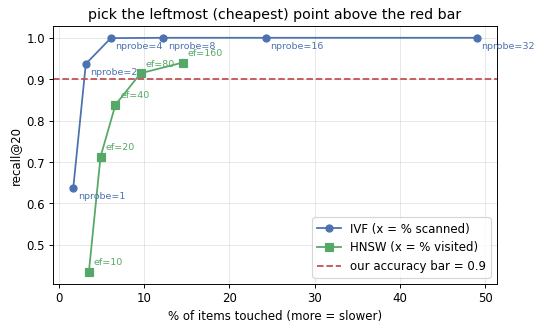

In [52]:
bar = 0.90
plt.figure(figsize=(6.5,4))
plt.plot([r[2] for r in ivf_rows], [r[1] for r in ivf_rows], "o-", color=BLUE, label="IVF (x = % scanned)")
for np_, rc, sc in ivf_rows: plt.annotate(f"nprobe={np_}", (sc, rc), textcoords="offset points", xytext=(4,-9), fontsize=8, color=BLUE)
plt.plot([r[2]/N*100 for r in hnsw_rows], [r[1] for r in hnsw_rows], "s-", color=GREEN, label="HNSW (x = % visited)")
for ef, rc, vi in hnsw_rows: plt.annotate(f"ef={ef}", (vi/N*100, rc), textcoords="offset points", xytext=(4,6), fontsize=8, color=GREEN)
plt.axhline(bar, color=RED, ls="--", label=f"our accuracy bar = {bar}")
plt.xlabel("% of items touched (more = slower)"); plt.ylabel("recall@20"); plt.legend()
plt.title("pick the leftmost (cheapest) point above the red bar"); plt.show()
ivf_ok = [r for r in ivf_rows if r[1] >= bar]
if ivf_ok:
    best = min(ivf_ok, key=lambda r: r[2])
    print(f"cheapest IVF setting that clears recall {bar}: nprobe={best[0]}  ->  {best[1]:.2f} recall while scanning only {best[2]:.1f}%")

**How to read this:** anything **above the red line** is accurate enough; among those, you want
the one **furthest left** (least work). Here `nprobe=2` clears the bar while scanning just ~3%.
That's your operating point. If your product needed higher recall, you'd slide right to a pricier
setting — a deliberate, measured choice, not a guess.

## Step 17 · The classic decision — HNSW vs IVF-PQ

**Plain words.** These two are the usual finalists. The deciding factor is usually **memory**:

| Your situation | Pick |
|---|---|
| Want highest recall and have **RAM to spare** | **HNSW** (turn up `efSearch`) |
| **Tight memory** budget | **IVF-PQ** (crayon-codes are tiny) |
| **Huge, rarely-changing** corpus | **IVF-PQ** (or ScaNN) |
| Items **update often** (freshness matters) | **HNSW** is often easier to update |
| Queries have **exact names / rare words** | add a **hybrid lexical** layer (next step) |

Our own numbers show the core tension: HNSW got high recall but **stores full vectors** (heavy);
IVF-PQ matched recall at **16× less memory**.

In [55]:
print("from this notebook's own runs:")
print(f"  HNSW (efSearch=160): recall {hnsw_rows[-1][1]:.2f},  memory {X.nbytes/1e3:.0f} KB  (stores full vectors)")
print(f"  IVF-PQ (nprobe=8)  : recall {recall_of(lambda q,k: ivf_pq(q,k,nprobe=8)):.2f},  memory {codes.nbytes/1e3:.0f} KB  ({X.nbytes/codes.nbytes:.0f}x less)")
print("\nrule of thumb:  short on memory -> IVF-PQ  |  short on recall & have memory -> HNSW")

from this notebook's own runs:
  HNSW (efSearch=160): recall 0.94,  memory 768 KB  (stores full vectors)
  IVF-PQ (nprobe=8)  : recall 1.00,  memory 48 KB  (16x less)

rule of thumb:  short on memory -> IVF-PQ  |  short on recall & have memory -> HNSW


## Step 18 · Hybrid — mix vector search with keyword search

**The gap.** Vector (dense) search is great at *meaning* ("brand-safe fitness creators") but can
**fumble exact names and rare words** — it thinks lots of items are "similar enough" and the one
you literally named gets lost in the crowd.

**Plain words.** **Keyword search (BM25)** is the opposite: it nails exact tokens (a specific
name, an SKU, a compliance phrase) but ignores meaning. **Hybrid** runs **both** and blends their
scores: `final = α·(vector score) + (1−α)·(keyword score)`. Use it whenever exact names or rare
terms matter. (LinkedIn systems like Nano / Galene / HostedSearch do this.)

**What the code does:** 150 "find this exact item" queries land in crowded topics. We check how
often dense-only finds the target vs hybrid (dense + a keyword exact-match).

on 150 'find this exact item' queries:
  dense (meaning) only : recall@20 = 0.77   (the exact item often gets lost)
  hybrid (meaning+keyword): recall@20 = 1.00   (keyword pins the exact match)


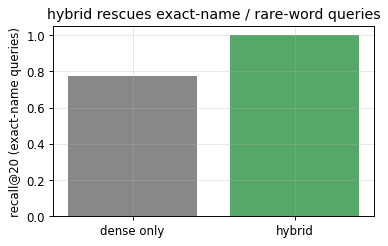

In [57]:
targets = rng.choice(N, 150, replace=False)          # 150 'I want THIS specific item' queries
def dense_topk(qv, k=20): return list(np.argsort(-(X @ qv))[:k])
def keyword_match(item_id): return [item_id]          # BM25 on a rare exact token -> that exact item

dense_hit = hybrid_hit = 0
for t in targets:
    qv = X[t] + rng.normal(0, 0.3, DIM)               # a query in a CROWDED neighborhood
    dtop = dense_topk(qv, 20)
    dense_hit  += int(t in dtop)                       # did meaning-search find the exact item?
    hybrid_hit += int(t in set(dtop) | set(keyword_match(t)))   # dense OR keyword
print("on 150 'find this exact item' queries:")
print(f"  dense (meaning) only : recall@20 = {dense_hit/len(targets):.2f}   (the exact item often gets lost)")
print(f"  hybrid (meaning+keyword): recall@20 = {hybrid_hit/len(targets):.2f}   (keyword pins the exact match)")
plt.figure(figsize=(4.6,3)); plt.bar(["dense only","hybrid"], [dense_hit/len(targets), hybrid_hit/len(targets)], color=[GRAY, GREEN])
plt.ylabel("recall@20 (exact-name queries)"); plt.title("hybrid rescues exact-name / rare-word queries"); plt.show()

**How to read this:** for exact-name queries, meaning-only search missed the target ~1 in 4
times (it drowned among similar items); **hybrid caught it every time** because the keyword side
pins the exact match. Meaning-search and keyword-search cover each other's blind spots — that's
why production retrieval usually runs both.

---
## Recap — what you just learned

**The core trade.** Exact search checks every item (correct but slow, cost grows with size). ANN
checks a fraction and accepts a little **recall loss** (graded by **recall@k** vs an answer key).

**Three ways to skip work:**
- **IVF** — group items into cells; open only the nearest `nprobe` cells. *Dial: nprobe.*
- **PQ / IVF-PQ** — squash vectors into tiny crayon-codes to save memory; use a small **exact
  rerank** to win back the accuracy PQ lost. *Dials: code size, rerank depth.*
- **HNSW** — link items into a graph and **walk** to the answer; a shortlist of size `efSearch`
  keeps you from getting stuck. *Dial: efSearch.*
- **ScaNN** — the **blurry-score → sharp-rerank** funnel, done well.

**Choosing & tuning.** No universal best — **sweep the dial, plot recall vs work, pick the
cheapest setting above your accuracy bar.** Short on memory → **IVF-PQ**; short on recall with
memory to spare → **HNSW**. Add **hybrid dense + keyword (BM25)** when exact names / rare words
matter.

**Where this fits.** M13 is the fast index behind M12's retrieval funnel. The vectors it searches
come from M11's embeddings, trained as **contrastive encoders** — which is **M14**, up next.